In [12]:
#K-medias es un algoritmo de agrupamiento por particiones cuyo objetivo es separar los objetos
#en K conjuntos disjuntos minimizando la suma de distancias al cuadrado de los objetos
#de cada grupo. 
#Importamos los datos
import pandas as pd
url_datos = 'https://drive.google.com/uc?id=1OzVlp4RsT63W6d18_Zc5WmUonLXMDNL8'
mexpr = pd.read_csv(url_datos, delimiter='\t')
mexpr_toy = mexpr.iloc[0:49, 0:19] #Coger un conjunto pequeño de los datos

print(f"Dimensiones originales: {mexpr.shape}")
mexpr_toy.head()

Dimensiones originales: (1500, 473)


,TCGA-D9-A4Z6-06,TCGA-EE-A2MQ-06,TCGA-EE-A3AF-06,TCGA-ER-A19F-06,TCGA-EE-A2MF-06,TCGA-EE-A2MJ-06,TCGA-BF-AAP4-01,TCGA-D3-A8GM-06,TCGA-GN-A26A-06,TCGA-EB-A3XE-01,TCGA-DA-A1I0-06,TCGA-FR-A3R1-01,TCGA-EE-A3AA-06,TCGA-W3-AA21-06,TCGA-D9-A6EA-06,TCGA-D3-A5GU-06,TCGA-EE-A29X-06,TCGA-EB-A4IS-01,TCGA-GF-A769-01
TYRP1,7.941545,2.750463,-5.566030,-4.907263,5.546815,7.036795,1.296667,8.453333,-4.295078,-2.822735,5.343145,-7.718614,-7.908148,4.485929,4.139340,-1.057352,-0.652172,6.943202,-5.958273
RPS4Y1,3.475878,-9.252088,-8.781994,-1.866586,-7.544166,0.983460,3.230248,1.556010,-8.687076,-8.216183,3.064411,2.580197,2.195396,-1.716290,2.127876,2.774703,-8.799704,0.504181,3.337378
KRT6A,-2.734785,0.420073,0.026095,0.850417,-2.374815,3.097854,2.583622,-2.734785,-1.190053,13.664241,-0.072284,-1.998570,6.665974,-2.734785,-1.937108,-2.734785,-0.754175,5.124605,-1.942097
XIST,-2.903056,8.320289,6.928525,-3.042341,9.475711,-3.487538,-2.690857,-3.487538,8.461294,6.168198,-3.487538,-1.380218,-1.269842,0.339875,-2.179177,-3.487538,6.039122,8.429310,-2.127342
KRT14,-3.653679,-2.898792,-0.531967,0.375261,-0.798866,1.482611,1.573041,-3.232954,0.714726,13.313004,-1.176080,-0.716749,4.210739,-3.653679,0.600907,-3.653679,-1.426185,6.348977,-2.152469


In [2]:
#Importamos librerias y definimos el algoritmo y sus parámetros
from sklearn.cluster import KMeans
from sklearn import metrics, preprocessing

k_means = KMeans(n_clusters=3)  #el n. de clusters es relevante para el resultado
datos = mexpr_toy.transpose()   #primero transponemos la matriz
cluster_predict=k_means.fit_predict(datos)

#añadimos el resultado a una tabla para qeu sea mas manejable
clusters = pd.DataFrame(cluster_predict, index=datos.index, columns=['cluster'])
clusters

,cluster
TCGA-D9-A4Z6-06,0
TCGA-EE-A2MQ-06,2
TCGA-EE-A3AF-06,0
TCGA-ER-A19F-06,2
TCGA-EE-A2MF-06,2
TCGA-EE-A2MJ-06,0
TCGA-BF-AAP4-01,0
TCGA-D3-A8GM-06,0
TCGA-GN-A26A-06,2
TCGA-EB-A3XE-01,1


In [3]:
#Ver el tamaño de cada cluster
print("Tamaño de cada cluster")
size=clusters['cluster'].value_counts()
size

Tamaño de cada cluster


cluster
0    12
2     6
1     1
Name: count, dtype: int64

<Axes: >

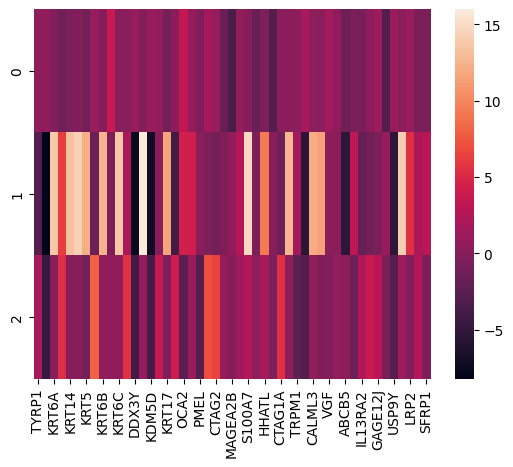

In [4]:
#Visualizar los perfiles de expresión genética
import seaborn as sns
centers=pd.DataFrame(k_means.cluster_centers_, columns=list(datos))
sns.heatmap(centers)

In [10]:
#calcular la bondad del clustering
from math import floor
k_means = KMeans(n_clusters=3)
datos = mexpr_toy.transpose()
cluster_predict = k_means.fit_predict(datos)

#Con el resultado del cluster podemos calcular índices
indice_silhouette = metrics.silhouette_score(datos, cluster_predict)
print("Índice Silhouette: "+str(indice_silhouette))
indice_CH = metrics.calinski_harabasz_score(datos, cluster_predict)
print("Índice de Calinski-Harabasz: "+ str(indice_CH))


Índice Silhouette: 0.06476370665151499
Índice de Calinski-Harabasz: 2.36321286966031
